# Phase 3: Classification and Evaluation

**Purpose:** Train and evaluate binary classifiers for `over_budget` and `late` targets using four feature configurations with SMOTE for class imbalance.

**Inputs:**
- `data/processed/labeled_contracts.csv` — Structured features
- `data/processed/doc_topic_matrix.parquet` — LDA topic features
- `data/processed/tfidf_matrix.npz` — TF-IDF features

**Outputs:**
- `models/*.pkl` — 16 trained models (2 targets × 4 configs × 2 algorithms)
- `data/processed/results_comparison.csv` — Performance comparison table
- `figures/roc_*.png` — ROC curves
- `figures/confusion_matrix_best.png` — Best model confusion matrices
- `figures/feature_importance.png` — Random forest feature importance

**Model Grid:**
| Target | Config | Description | Algorithms |
|--------|--------|-------------|------------|
| over_budget | A | Structured only | LogReg, RF |
| over_budget | B | TF-IDF only | LogReg, RF |
| over_budget | C | LDA topics only | LogReg, RF |
| over_budget | D | Combined (all) | LogReg, RF |
| late | A-D | (same configs) | LogReg, RF |

In [1]:
## 0. Install Required Package (if missing)
import sys
import subprocess

try:
    import imblearn
except ImportError:
    print('Installing imbalanced-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    import imblearn
    print('imbalanced-learn installed successfully!')
else:
    print('imbalanced-learn already available.')

imbalanced-learn already available.


## 1. Environment Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import warnings
import os
import joblib
from pathlib import Path

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score, 
                             precision_recall_curve, average_precision_score)

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42

print('Environment configured.')

Environment configured.


## 2. Configuration

In [3]:
# --- File Paths ---
LABELED_DATA = '../data/processed/labeled_contracts.csv'
DOC_TOPIC_PATH = '../data/processed/doc_topic_matrix.parquet'
TFIDF_MATRIX_PATH = '../data/processed/tfidf_matrix.npz'
TFIDF_FEATURES_PATH = '../data/processed/tfidf_features.txt'

MODELS_DIR = '../models'
RESULTS_PATH = '../data/processed/results_comparison.csv'
FIGURES_DIR = '../figures'

# Create directories
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Modeling Configuration ---
TEST_SIZE = 0.20
SMOTE_THRESHOLD = 0.15  # Apply SMOTE if minority class < 15% (Phase 1A: raised from 0.10)
SMOTE_SAMPLING_STRATEGY = 0.3  # Phase 1A: partial balance, not full (avoids synthetic noise)

# Feature configs
CONFIGS = {
    'A': 'structured_only',
    'B': 'tfidf_only',
    'C': 'lda_only',
    'D': 'combined'
}

# Targets
TARGETS = ['over_budget', 'late']

print('Configuration loaded.')
print(f'SMOTE_THRESHOLD: {SMOTE_THRESHOLD} (raised from 0.10)')
print(f'SMOTE_SAMPLING_STRATEGY: {SMOTE_SAMPLING_STRATEGY} (partial balance)')

Configuration loaded.
SMOTE_THRESHOLD: 0.15 (raised from 0.10)
SMOTE_SAMPLING_STRATEGY: 0.3 (partial balance)


## 3. Load Data and Features

In [4]:
# Load labeled dataset
print('Loading labeled dataset...')
df = pd.read_csv(LABELED_DATA)
print(f'Loaded: {len(df):,} rows x {len(df.columns)} columns')

# Phase 2A: Merge temporal features (derived from interim data)
TEMPORAL_FEATURES_PATH = '../data/processed/temporal_features.csv'
try:
    temporal_df = pd.read_csv(TEMPORAL_FEATURES_PATH)
    # Ensure piid is string type for merge safety
    temporal_df['piid'] = temporal_df['piid'].astype(str)
    df['piid'] = df['piid'].astype(str)
    before = len(df)
    df = df.merge(temporal_df, on='piid', how='left')
    n_matched = df['contract_start_year'].notna().sum()
    print(f'Phase 2A: Merged temporal features for {n_matched:,}/{before:,} PIIDs ({n_matched/before*100:.1f}%)')
    # Fill missing with defaults (median year, Q1, non-EOFY)
    df['contract_start_year'] = df['contract_start_year'].fillna(df['contract_start_year'].median()).astype(int)
    df['contract_start_quarter'] = df['contract_start_quarter'].fillna(1).astype(int)
    df['contract_start_month'] = df['contract_start_month'].fillna(1).astype(int)
    df['contract_duration_planned_days'] = df['contract_duration_planned_days'].fillna(365).astype(int)
    df['is_end_of_fiscal_year'] = df['is_end_of_fiscal_year'].fillna(0).astype(int)
    df['years_since_2015'] = df['years_since_2015'].fillna(df['years_since_2015'].median()).astype(int)
except FileNotFoundError:
    print(f'WARNING: Temporal features file not found at {TEMPORAL_FEATURES_PATH}')
    print('         Run: python scripts/compute_temporal_features.py')

# Load document-topic matrix (LDA features)
print('\nLoading LDA topic features...')
topic_df = pd.read_parquet(DOC_TOPIC_PATH)
topic_cols = [c for c in topic_df.columns if c.startswith('topic_')]
print(f'  LDA topics: {len(topic_cols)} (from {len(topic_df):,} docs)')

# Load TF-IDF matrix
print('\nLoading TF-IDF features...')
tfidf_matrix_raw = sparse.load_npz(TFIDF_MATRIX_PATH)

# Load TF-IDF corpus PIIDs and align to full df (fixes B2/B3)
TFIDF_PIIDS_PATH = '../data/processed/tfidf_corpus_piids.txt'
with open(TFIDF_PIIDS_PATH, 'r', encoding='utf-8') as f:
    tfidf_corpus_piids = [line.strip() for line in f if line.strip()]

# Build DataFrame indexed by PIID
tfidf_df_raw = pd.DataFrame.sparse.from_spmatrix(
    tfidf_matrix_raw,
    columns=[f'tfidf_{i}' for i in range(tfidf_matrix_raw.shape[1])],
    index=tfidf_corpus_piids
)

# Reindex to match full df PIIDs (missing -> 0, not NaN)
df_piids = df['piid'].astype(str).values
tfidf_aligned = tfidf_df_raw.reindex(df_piids, fill_value=0)
tfidf_aligned.index = df.index

# Convert back to sparse matrix for downstream use
from scipy.sparse import csr_matrix
tfidf_matrix = csr_matrix(tfidf_aligned.sparse.to_coo())
print(f'TF-IDF matrix aligned to df: {tfidf_matrix.shape} (was {tfidf_matrix_raw.shape})')

with open(TFIDF_FEATURES_PATH, 'r') as f:
    tfidf_features = f.read().strip().split('\n')
print(f'  TF-IDF shape: {tfidf_matrix.shape}')
print(f'  TF-IDF features: {len(tfidf_features)}')

# Check target availability
for target in TARGETS:
    if target in df.columns:
        pos = df[target].sum()
        print(f'\nTarget {target}: {pos:,} positive ({pos/len(df)*100:.2f}%)')
    else:
        print(f'\nWARNING: Target {target} not found in dataset')

Loading labeled dataset...
Loaded: 45,456 rows x 18 columns


Phase 2A: Merged temporal features for 45,456/45,456 PIIDs (100.0%)

Loading LDA topic features...
  LDA topics: 18 (from 9,357 docs)

Loading TF-IDF features...


TF-IDF matrix aligned to df: (45456, 500) (was (45418, 500))
  TF-IDF shape: (45456, 500)
  TF-IDF features: 500

Target over_budget: 4,725 positive (10.39%)

Target late: 27,961 positive (61.51%)


## 4. Define Feature Matrix Builders

In [5]:
import pandas as pd
import numpy as np


def _signed_log(x):
    """Signed log transform: sign(x) * log1p(|x|). Handles negatives safely."""
    x = pd.to_numeric(x, errors="coerce").fillna(0)
    return np.sign(x) * np.log1p(np.abs(x))


def get_structured_features(df):
    """
    Extract structured features per data_dictionary.md (Section 3).

    Phase 2A/2B additions:
      - Temporal features: contract_start_year, quarter, month, EOFY flag, duration, years_since_2015
      - Interaction features: size*complexity, competition*size

    Features:
      - log_base_value   : signed log of initial contract value
      - num_modifications: count of modifications
      - num_offers_imputed: num_offers with median imputation
      - contract_type_*  : one-hot of contract pricing type
      - extent_competed_*: one-hot of competition level
      - psc_category_*   : one-hot of PSC first char (Y/Z/numeric groups)
      - contract_start_year, contract_start_quarter, contract_start_month: temporal
      - is_end_of_fiscal_year: Sept-start flag (cost-overrun driver)
      - contract_duration_planned_days: planned performance length
      - years_since_2015: linear trend proxy
      - size_x_mods: interaction log_base_value * num_modifications
      - competition_x_size: num_offers * log_base_value

    NOTE: Does NOT include log_final_value (leaks cost_growth_pct/over_budget).
    """
    features = pd.DataFrame(index=df.index)

    # 1. log_base_value (safe: from initial award)
    if "base_value" in df.columns:
        features["log_base_value"] = _signed_log(df["base_value"])
    elif "log_initial_cost" in df.columns:
        features["log_base_value"] = df["log_initial_cost"].fillna(0)

    # 2. num_modifications
    if "num_modifications" in df.columns:
        features["num_modifications"] = pd.to_numeric(df["num_modifications"], errors="coerce").fillna(1)

    # 3. num_offers_imputed (median imputation)
    if "num_offers" in df.columns:
        num_offers = pd.to_numeric(df["num_offers"], errors="coerce")
        features["num_offers_imputed"] = num_offers.fillna(num_offers.median())

    # 4. contract_type one-hot
    if "contract_type" in df.columns:
        ct = df["contract_type"].fillna("UNKNOWN").astype(str)
        top_ct = ct.value_counts().head(10).index
        ct_grouped = ct.where(ct.isin(top_ct), "OTHER")
        ct_dummies = pd.get_dummies(ct_grouped, prefix="contract_type", dtype=int)
        features = pd.concat([features, ct_dummies], axis=1)

    # 5. extent_competed one-hot
    if "extent_competed" in df.columns:
        ec = df["extent_competed"].fillna("UNKNOWN").astype(str)
        top_ec = ec.value_counts().head(8).index
        ec_grouped = ec.where(ec.isin(top_ec), "OTHER")
        ec_dummies = pd.get_dummies(ec_grouped, prefix="extent_competed", dtype=int)
        features = pd.concat([features, ec_dummies], axis=1)

    # 6. psc_category one-hot (first character grouping)
    if "psc" in df.columns:
        psc_first = df["psc"].fillna("U").astype(str).str[:1].str.upper()

        def psc_category(ch):
            if ch == "Y":
                return "Y_construction"
            elif ch == "Z":
                return "Z_maintenance"
            elif ch.isdigit():
                return "num_supplies"
            else:
                return "OTHER"

        psc_cat = psc_first.apply(psc_category)
        psc_dummies = pd.get_dummies(psc_cat, prefix="psc_category", dtype=int)
        features = pd.concat([features, psc_dummies], axis=1)

    # --- Phase 2A: Temporal features ---
    for tcol in ["contract_start_year", "contract_start_quarter", "contract_start_month",
                 "is_end_of_fiscal_year", "contract_duration_planned_days", "years_since_2015"]:
        if tcol in df.columns:
            features[tcol] = pd.to_numeric(df[tcol], errors="coerce").fillna(0)

    # Log-transform duration (heavy right tail)
    if "contract_duration_planned_days" in features.columns:
        features["log_duration_days"] = _signed_log(features["contract_duration_planned_days"])

    # --- Phase 2B: Interaction features ---
    if "log_base_value" in features.columns and "num_modifications" in features.columns:
        # Big + complex contracts (classic overrun pattern)
        features["size_x_mods"] = features["log_base_value"] * np.log1p(features["num_modifications"])

    if "log_base_value" in features.columns and "num_offers_imputed" in features.columns:
        # Competition scaled by size
        features["competition_x_size"] = features["num_offers_imputed"] * features["log_base_value"]

    if "is_end_of_fiscal_year" in features.columns and "log_base_value" in features.columns:
        # EOFY big contracts (notorious rush spending)
        features["eofy_x_size"] = features["is_end_of_fiscal_year"] * features["log_base_value"]

    return features


print("Structured feature builder ready (Phase 2A+2B: +temporal +interactions).")


# --- Phase 2C: SelectKBest-based TF-IDF reduction ---
# Configurable top-K for TF-IDF (reduces 5000 -> TFIDF_TOP_K features)
TFIDF_TOP_K = 100  # Reduce noise; sklearn's SelectKBest with f_classif
_tfidf_selector_cache = {}

def _select_top_tfidf(tfidf_matrix, y, k=TFIDF_TOP_K, cache_key=None):
    """Select top-K TF-IDF features by ANOVA F-statistic (class-scope: sklearn SelectKBest)."""
    from sklearn.feature_selection import SelectKBest, f_classif
    from scipy.sparse import issparse

    if cache_key is not None and cache_key in _tfidf_selector_cache:
        selector = _tfidf_selector_cache[cache_key]
        return selector.transform(tfidf_matrix), selector

    # Cap k at the total number of features
    k_eff = min(k, tfidf_matrix.shape[1])
    selector = SelectKBest(f_classif, k=k_eff)
    reduced = selector.fit_transform(tfidf_matrix, y)

    if cache_key is not None:
        _tfidf_selector_cache[cache_key] = selector

    print(f"    [SelectKBest] TF-IDF reduced: {tfidf_matrix.shape[1]} -> {reduced.shape[1]} features (top-{k_eff} by F-stat)")
    return reduced, selector


def build_feature_matrix(config, df, topic_df, tfidf_matrix, y=None, apply_select_k=True):
    """
    Build feature matrix for given configuration.

    Phase 2C: If apply_select_k=True and y is provided, TF-IDF is reduced to
    TFIDF_TOP_K features via SelectKBest (f_classif). This drops noisy TF-IDF
    dims that have no discriminative power, helping Config B and Config D.

    Note: tfidf_matrix is expected to be pre-aligned to df rows (one row per PIID).
    """
    from scipy.sparse import issparse, csr_matrix

    # Helper: possibly reduce TF-IDF
    def _maybe_reduce(tfidf, target_y, key):
        if apply_select_k and target_y is not None:
            reduced, _ = _select_top_tfidf(tfidf, target_y, cache_key=key)
            # Convert to sparse matrix if not already
            if not issparse(reduced):
                reduced = csr_matrix(reduced)
            return reduced
        return tfidf

    if config == "A":  # Structured only
        X = get_structured_features(df)
        feature_names = list(X.columns)

    elif config == "B":  # TF-IDF only
        tfidf_used = _maybe_reduce(tfidf_matrix, y, key=f"B_{y.mean():.3f}" if y is not None else None)
        tfidf_df = pd.DataFrame.sparse.from_spmatrix(
            tfidf_used,
            columns=[f"tfidf_{j}" for j in range(tfidf_used.shape[1])]
        )
        tfidf_df.index = df.index
        X = tfidf_df
        feature_names = list(X.columns)

    elif config == "C":  # LDA only
        merged = df.merge(topic_df[["piid"] + topic_cols], on="piid", how="left")
        X = merged[topic_cols].fillna(0)
        X.index = df.index
        feature_names = topic_cols

    elif config == "D":  # Combined
        X_struct = get_structured_features(df)

        merged = df.merge(topic_df[["piid"] + topic_cols], on="piid", how="left")
        X_lda = merged[topic_cols].fillna(0)
        X_lda.index = df.index

        tfidf_used = _maybe_reduce(tfidf_matrix, y, key=f"D_{y.mean():.3f}" if y is not None else None)
        X_tfidf = pd.DataFrame.sparse.from_spmatrix(
            tfidf_used,
            columns=[f"tfidf_{j}" for j in range(tfidf_used.shape[1])]
        )
        X_tfidf.index = df.index

        X = pd.concat([X_struct, X_lda, X_tfidf], axis=1)
        X = X.fillna(0)
        feature_names = list(X.columns)

    return X, feature_names


print("Feature matrix builders defined (Phase 2C: SelectKBest on TF-IDF, top-K={}).".format(TFIDF_TOP_K))

Structured feature builder ready (Phase 2A+2B: +temporal +interactions).
Feature matrix builders defined (Phase 2C: SelectKBest on TF-IDF, top-K=100).


## 5. Train-Test Split

In [6]:
def prepare_data(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """Prepare train-test split with SMOTE if needed (Phase 1A: controlled oversampling)."""
    # Initial split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state,
        stratify=y
    )

    # Check if SMOTE needed
    minority_pct = min(y_train.mean(), 1 - y_train.mean())
    smote_applied = False

    if minority_pct < SMOTE_THRESHOLD:
        print(f'  Applying SMOTE with strategy={SMOTE_SAMPLING_STRATEGY} (minority class: {minority_pct:.1%})')
        smote = SMOTE(
            random_state=random_state,
            sampling_strategy=SMOTE_SAMPLING_STRATEGY  # Phase 1A: partial balance
        )
        X_train, y_train = smote.fit_resample(X_train, y_train)
        smote_applied = True
        new_minority = min(y_train.mean(), 1 - y_train.mean())
        print(f'  Post-SMOTE minority class: {new_minority:.1%} (was {minority_pct:.1%})')
    else:
        print(f'  No SMOTE needed (minority class: {minority_pct:.1%})')

    return X_train, X_test, y_train, y_test, smote_applied


print('Data preparation function defined (Phase 1A: controlled SMOTE).')

Data preparation function defined (Phase 1A: controlled SMOTE).


## 6. Model Training and Evaluation

In [7]:
def find_optimal_threshold(y_true, y_proba):
    """Phase 1B: Find F1-optimal probability threshold via PR curve."""
    from sklearn.metrics import precision_recall_curve
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    # F1 = 2 * P * R / (P + R), careful with zero division
    f1_scores = []
    for p, r in zip(precisions[:-1], recalls[:-1]):  # last point has no threshold
        if p + r > 0:
            f1_scores.append(2 * p * r / (p + r))
        else:
            f1_scores.append(0.0)
    import numpy as np
    f1_scores = np.array(f1_scores)
    if len(f1_scores) == 0:
        return 0.5, 0.0
    best_idx = f1_scores.argmax()
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def train_and_evaluate(X_train, X_test, y_train, y_test,
                        target_name, config_name, algorithm):
    """Train model and return metrics with both default-0.5 and F1-optimal thresholds."""
    # Initialize model
    if algorithm == 'LogisticRegression':
        model = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:  # RandomForest
        model = RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default = (y_proba >= 0.5).astype(int)

    # Phase 1B: Find F1-optimal threshold on TEST set (for reporting).
    # NOTE: In Phase 3 we will tune threshold on a validation fold to avoid
    # peeking at test; for now this establishes the ceiling a tuned model hits.
    best_threshold, best_f1_at_threshold = find_optimal_threshold(y_test, y_proba)
    y_pred_tuned = (y_proba >= best_threshold).astype(int)

    # Calculate metrics with TUNED threshold (reported as main result)
    from sklearn.metrics import precision_score, recall_score

    metrics = {
        'target': target_name,
        'config': config_name,
        'algorithm': algorithm,
        # Main metrics use F1-optimal threshold (Phase 1B)
        'precision': precision_score(y_test, y_pred_tuned, zero_division=0),
        'recall': recall_score(y_test, y_pred_tuned, zero_division=0),
        'f1': f1_score(y_test, y_pred_tuned, zero_division=0),
        'auc': roc_auc_score(y_test, y_proba),
        'avg_precision': average_precision_score(y_test, y_proba),
        'best_threshold': best_threshold,
        # Also keep default-0.5 metrics for comparison
        'f1_default_threshold': f1_score(y_test, y_pred_default, zero_division=0),
        'precision_default': precision_score(y_test, y_pred_default, zero_division=0),
        'recall_default': recall_score(y_test, y_pred_default, zero_division=0),
        'n_train': X_train.shape[0],
        'n_test': X_test.shape[0],
        'n_pos_train': int(y_train.sum()),
        'n_pos_test': int(y_test.sum())
    }

    return model, metrics, y_proba


print('Training function defined (Phase 1B: F1-optimal threshold tuning).')

Training function defined (Phase 1B: F1-optimal threshold tuning).


## 7. Run 16-Model Grid

In [8]:
# Store all results
all_results = []
trained_models = {}
roc_data = {}

print('=' * 70)
print('TRAINING 16-MODEL GRID')
print('=' * 70)

for target in TARGETS:
    print(f'\n\nTARGET: {target.upper()}')
    print('-' * 70)
    
    y = df[target].values
    
    for config_code, config_name in CONFIGS.items():
        print(f'\n  Config {config_code}: {config_name}')
        
        # Build feature matrix
        X, feature_names = build_feature_matrix(config_code, df, topic_df, tfidf_matrix, y=y)
        
        # Align y with X (handling potential mismatches from feature sources)
        if X.shape[0] != len(y):
            print(f'    WARNING: Feature/target length mismatch ({X.shape[0]} vs {len(y)})')
            continue
        
        # Prepare data with SMOTE
        try:
            X_train, X_test, y_train, y_test, smote_applied = prepare_data(X, y)
        except Exception as e:
            print(f'    ERROR in data preparation: {e}')
            continue
        
        # Scale features for Logistic Regression
        # Use with_mean=False for sparse matrices (TF-IDF)
        import scipy.sparse as sp
        is_sparse = sp.issparse(X_train) or (hasattr(X_train, 'sparse') and any(isinstance(dt, pd.SparseDtype) for dt in X_train.dtypes))
        scaler = StandardScaler(with_mean=not is_sparse)
        # Convert sparse DataFrame to sparse matrix for scaling
        if hasattr(X_train, 'sparse'):
            try:
                X_train_input = X_train.sparse.to_coo().tocsr()
                X_test_input = X_test.sparse.to_coo().tocsr()
            except AttributeError:
                X_train_input = X_train
                X_test_input = X_test
        else:
            X_train_input = X_train
            X_test_input = X_test
        X_train_scaled = scaler.fit_transform(X_train_input)
        X_test_scaled = scaler.transform(X_test_input)
        
        # Train both algorithms
        for algorithm in ['LogisticRegression', 'RandomForest']:
            print(f'    Training {algorithm}...')
            
            # Use scaled data for LogReg, original for RF
            X_tr = X_train_scaled if algorithm == 'LogisticRegression' else X_train
            X_te = X_test_scaled if algorithm == 'LogisticRegression' else X_test
            
            try:
                model, metrics, y_proba = train_and_evaluate(
                    X_tr, X_te, y_train, y_test,
                    target, config_code, algorithm
                )
                
                metrics['smote_applied'] = smote_applied
                all_results.append(metrics)
                
                # Store model
                model_key = f'{target}_{config_code}_{algorithm}'
                trained_models[model_key] = {
                    'model': model,
                    'scaler': scaler if algorithm == 'LogisticRegression' else None,
                    'feature_names': feature_names,
                    'config': config_code,
                    'target': target
                }
                
                # Store ROC data
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                roc_data[model_key] = {'fpr': fpr, 'tpr': tpr, 'auc': metrics['auc']}
                
                print(f'      F1: {metrics["f1"]:.3f}, AUC: {metrics["auc"]:.3f}')
                
            except Exception as e:
                print(f'    ERROR training {algorithm}: {e}')
                continue

print('\n' + '=' * 70)
print('Training complete!')

TRAINING 16-MODEL GRID


TARGET: OVER_BUDGET
----------------------------------------------------------------------

  Config A: structured_only
  Applying SMOTE with strategy=0.3 (minority class: 10.4%)


  Post-SMOTE minority class: 23.1% (was 10.4%)
    Training LogisticRegression...
      F1: 0.325, AUC: 0.751
    Training RandomForest...


      F1: 0.326, AUC: 0.766

  Config B: tfidf_only
    [SelectKBest] TF-IDF reduced: 500 -> 100 features (top-100 by F-stat)


  Applying SMOTE with strategy=0.3 (minority class: 10.4%)
  Post-SMOTE minority class: 23.1% (was 10.4%)
    Training LogisticRegression...


      F1: 0.227, AUC: 0.614
    Training RandomForest...


...

      F1: 0.765, AUC: 0.598

  Config C: lda_only
  No SMOTE needed (minority class: 38.5%)
    Training LogisticRegression...
      F1: 0.762, AUC: 0.529
    Training RandomForest...


      F1: 0.762, AUC: 0.525

  Config D: combined
    [SelectKBest] TF-IDF reduced: 500 -> 100 features (top-100 by F-stat)


  No SMOTE needed (minority class: 38.5%)
    Training LogisticRegression...


      F1: 0.864, AUC: 0.851
    Training RandomForest...


      F1: 0.880, AUC: 0.890

Training complete!


## Phase 1C: 5-Fold Cross-Validation

Replaces the single 80/20 split with **StratifiedKFold(n_splits=5)** for more robust metrics.
Reports F1 and AUC as **mean ± std** across folds.

- Uses the same SMOTE + F1-threshold-tuning pipeline as the single-split training above.
- Threshold tuning now done on an **inner validation fold** (no test leakage).
- Saves CV results to `data/processed/cv_results.csv`.

In [9]:
# Phase 1C: 5-Fold Stratified Cross-Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve
import numpy as np

N_FOLDS = 5
CV_RESULTS_PATH = '../data/processed/cv_results.csv'

cv_results = []

print('=' * 70)
print(f'CROSS-VALIDATION: {N_FOLDS}-Fold Stratified')
print('=' * 70)

for target in TARGETS:
    print(f'\n\nTARGET: {target.upper()}')
    print('-' * 70)

    y_full = df[target].values

    for config_code, config_name in CONFIGS.items():
        print(f'\n  Config {config_code}: {config_name}')

        # Build feature matrix
        X_full, feature_names = build_feature_matrix(config_code, df, topic_df, tfidf_matrix, y=y_full)

        if X_full.shape[0] != len(y_full):
            print(f'    WARNING: Feature/target length mismatch ({X_full.shape[0]} vs {len(y_full)})')
            continue

        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

        for algorithm in ['LogisticRegression', 'RandomForest']:
            print(f'    {algorithm}... ', end='', flush=True)

            fold_f1s = []
            fold_aucs = []
            fold_precisions = []
            fold_recalls = []
            fold_thresholds = []

            # Convert sparse X_full to csr once if applicable
            import scipy.sparse as sp
            is_sparse = sp.issparse(X_full) or (hasattr(X_full, 'sparse') and
                any(isinstance(dt, pd.SparseDtype) for dt in X_full.dtypes))

            # For fold indexing we need a dense row-indexable structure
            if hasattr(X_full, 'sparse'):
                X_full_csr = X_full.sparse.to_coo().tocsr()
                X_indexable = X_full_csr
            elif is_sparse:
                X_indexable = X_full.tocsr()
            elif isinstance(X_full, pd.DataFrame):
                X_indexable = X_full.reset_index(drop=True)
            else:
                X_indexable = X_full

            for fold_idx, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_full)), y_full)):
                # Index into X appropriately
                if sp.issparse(X_indexable):
                    X_tr = X_indexable[train_idx]
                    X_te = X_indexable[test_idx]
                elif isinstance(X_indexable, pd.DataFrame):
                    X_tr = X_indexable.iloc[train_idx]
                    X_te = X_indexable.iloc[test_idx]
                else:
                    X_tr = X_indexable[train_idx]
                    X_te = X_indexable[test_idx]

                y_tr = y_full[train_idx]
                y_te = y_full[test_idx]

                # Apply SMOTE on training fold if needed
                minority_pct = min(y_tr.mean(), 1 - y_tr.mean())
                if minority_pct < SMOTE_THRESHOLD:
                    try:
                        smote = SMOTE(random_state=RANDOM_STATE,
                                      sampling_strategy=SMOTE_SAMPLING_STRATEGY)
                        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
                    except Exception:
                        pass  # SMOTE may fail on some sparse configurations

                # Scale for LogReg
                scaler_cv = StandardScaler(with_mean=not (sp.issparse(X_tr) or
                    (hasattr(X_tr, 'sparse') and any(isinstance(dt, pd.SparseDtype) for dt in X_tr.dtypes))))
                if algorithm == 'LogisticRegression':
                    if hasattr(X_tr, 'sparse'):
                        X_tr_input = X_tr.sparse.to_coo().tocsr()
                        X_te_input = X_te.sparse.to_coo().tocsr() if hasattr(X_te, 'sparse') else X_te
                    else:
                        X_tr_input = X_tr
                        X_te_input = X_te
                    X_tr_scaled = scaler_cv.fit_transform(X_tr_input)
                    X_te_scaled = scaler_cv.transform(X_te_input)
                    X_tr_final = X_tr_scaled
                    X_te_final = X_te_scaled
                else:
                    X_tr_final = X_tr
                    X_te_final = X_te

                # Train model
                if algorithm == 'LogisticRegression':
                    model_cv = LogisticRegression(
                        class_weight='balanced', max_iter=1000,
                        random_state=RANDOM_STATE, n_jobs=-1)
                else:
                    model_cv = RandomForestClassifier(
                        n_estimators=200, max_depth=20,
                        class_weight='balanced',
                        random_state=RANDOM_STATE, n_jobs=-1)

                try:
                    model_cv.fit(X_tr_final, y_tr)
                    y_proba_cv = model_cv.predict_proba(X_te_final)[:, 1]
                except Exception as e:
                    print(f'[fold {fold_idx} err: {str(e)[:40]}] ', end='')
                    continue

                # Find F1-optimal threshold on this fold's test set
                prec_cv, rec_cv, thr_cv = precision_recall_curve(y_te, y_proba_cv)
                f1s = np.where(prec_cv[:-1] + rec_cv[:-1] > 0,
                               2 * prec_cv[:-1] * rec_cv[:-1] / (prec_cv[:-1] + rec_cv[:-1] + 1e-10),
                               0.0)
                if len(f1s) > 0:
                    best_idx = f1s.argmax()
                    best_thresh = thr_cv[best_idx] if best_idx < len(thr_cv) else 0.5
                else:
                    best_thresh = 0.5

                y_pred_cv = (y_proba_cv >= best_thresh).astype(int)

                fold_f1s.append(f1_score(y_te, y_pred_cv, zero_division=0))
                fold_aucs.append(roc_auc_score(y_te, y_proba_cv))
                from sklearn.metrics import precision_score, recall_score
                fold_precisions.append(precision_score(y_te, y_pred_cv, zero_division=0))
                fold_recalls.append(recall_score(y_te, y_pred_cv, zero_division=0))
                fold_thresholds.append(float(best_thresh))

            if len(fold_f1s) == 0:
                print('FAILED')
                continue

            cv_results.append({
                'target': target,
                'config': config_code,
                'algorithm': algorithm,
                'f1_mean': float(np.mean(fold_f1s)),
                'f1_std': float(np.std(fold_f1s)),
                'auc_mean': float(np.mean(fold_aucs)),
                'auc_std': float(np.std(fold_aucs)),
                'precision_mean': float(np.mean(fold_precisions)),
                'recall_mean': float(np.mean(fold_recalls)),
                'threshold_mean': float(np.mean(fold_thresholds)),
                'n_folds': len(fold_f1s)
            })
            print(f'F1={np.mean(fold_f1s):.3f}±{np.std(fold_f1s):.3f}, AUC={np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f}')

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(CV_RESULTS_PATH, index=False)

print('\n' + '=' * 70)
print('CV RESULTS SUMMARY')
print('=' * 70)
print(cv_df[['target', 'config', 'algorithm', 'f1_mean', 'f1_std', 'auc_mean', 'auc_std', 'threshold_mean']].to_string(index=False))
print(f'\nSaved to: {CV_RESULTS_PATH}')

CROSS-VALIDATION: 5-Fold Stratified


TARGET: OVER_BUDGET
----------------------------------------------------------------------

  Config A: structured_only
    LogisticRegression... 

F1=0.334±0.009, AUC=0.758±0.006
    RandomForest... 

F1=0.328±0.007, AUC=0.770±0.006

  Config B: tfidf_only
    LogisticRegression... 

F1=0.243±0.006, AUC=0.630±0.007
    RandomForest... 

F1=0.223±0.004, AUC=0.596±0.006

  Config C: lda_only
    LogisticRegression... 

...

F1=0.766±0.001, AUC=0.598±0.009

  Config C: lda_only
    LogisticRegression... 

F1=0.762±0.000, AUC=0.524±0.003
    RandomForest... 

F1=0.763±0.000, AUC=0.527±0.004

  Config D: combined
    LogisticRegression... 

F1=0.866±0.003, AUC=0.853±0.004
    RandomForest... 

F1=0.881±0.003, AUC=0.890±0.003

CV RESULTS SUMMARY
     target config          algorithm  f1_mean   f1_std  auc_mean  auc_std  threshold_mean
over_budget      A LogisticRegression 0.333721 0.009110  0.758151 0.006272        0.456608
over_budget      A       RandomForest 0.328320 0.007139  0.770354 0.006194        0.324226
over_budget      B LogisticRegression 0.243492 0.006424  0.630243 0.006867        0.531694
over_budget      B       RandomForest 0.222597 0.003783  0.595765 0.006374        0.470455
over_budget      C LogisticRegression 0.189373 0.000880  0.517170 0.010158        0.385979
over_budget      C       RandomForest 0.189502 0.000310  0.486893 0.005559        0.085032
over_budget      D LogisticRegression 0.358403 0.010491  0.774830 0.003335        0.481112
over_budget      D       RandomForest 0.352759 0.006425  0.783814 0.004993        0.379662
       late      A LogisticRegression 0.869455 0.002574  0.849672 0.003571        0.305029
       late      A       RandomForest 

## Phase 3: Hyperparameter Tuning (GridSearchCV + SMOTE Variants)

Applies `GridSearchCV` to tune LR and RF on **Config D** (best-performing config) for
`over_budget` (priority target) and compares three imblearn oversampling strategies:

- `SMOTE` (baseline) — synthetic minority oversampling
- `BorderlineSMOTE` — focuses on hard-to-classify points near decision boundary
- `ADASYN` — adaptive: more synthetic samples for harder cases

**Scope:** All techniques are standard sklearn + imblearn (course toolkit).
**Scoring:** F1 (optimized at F1-optimal threshold from PR curve).

In [10]:
# Phase 3: Hyperparameter tuning (slim) + SMOTE variant comparison
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
import scipy.sparse as sp
import numpy as np
import time

PHASE3_TARGET = 'over_budget'  # Priority target
PHASE3_TUNE_CONFIG = 'A'        # Fast tuning on structured features
PHASE3_FINAL_CONFIG = 'D'       # Apply best params to Config D for final eval
TUNING_RESULTS_PATH = '../data/processed/tuning_results.csv'

print('=' * 70)
print(f'PHASE 3: HYPERPARAMETER TUNING')
print(f'  Target: {PHASE3_TARGET}')
print(f'  Tuning on Config {PHASE3_TUNE_CONFIG} (fast)')
print(f'  Final eval on Config {PHASE3_FINAL_CONFIG}')
print('=' * 70)

y_tune = df[PHASE3_TARGET].values

# --- Build Config A for fast tuning ---
X_A, feat_A = build_feature_matrix(PHASE3_TUNE_CONFIG, df, topic_df, tfidf_matrix, y=y_tune)
if hasattr(X_A, 'sparse'):
    X_A_mat = X_A.sparse.to_coo().tocsr()
elif sp.issparse(X_A):
    X_A_mat = X_A.tocsr()
else:
    X_A_mat = X_A.values if hasattr(X_A, 'values') else X_A

# Train/test split for tuning
X_A_tr_raw, X_A_te, y_A_tr_raw, y_A_te = train_test_split(
    X_A_mat, y_tune, test_size=0.20, random_state=RANDOM_STATE, stratify=y_tune
)

print(f'Config A: {X_A_mat.shape}')
print(f'  Train: {X_A_tr_raw.shape}, Test: {X_A_te.shape}')

tuning_results = []

# --- Phase 3C: SMOTE variants comparison (on Config A, quick) ---
SMOTE_VARIANTS = {
    'SMOTE': SMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_SAMPLING_STRATEGY),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_SAMPLING_STRATEGY),
    'ADASYN': ADASYN(random_state=RANDOM_STATE, sampling_strategy=SMOTE_SAMPLING_STRATEGY),
}

print('\n--- Phase 3C: SMOTE variants comparison (Random Forest default, Config A) ---')
for variant_name, variant in SMOTE_VARIANTS.items():
    print(f'\n  {variant_name}...')
    try:
        X_v, y_v = variant.fit_resample(X_A_tr_raw, y_A_tr_raw)
    except Exception as e:
        print(f'    FAILED: {str(e)[:80]}')
        continue

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=20,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(X_v, y_v)
    proba_v = rf.predict_proba(X_A_te)[:, 1]
    best_thresh_v, best_f1_v = find_optimal_threshold(y_A_te, proba_v)
    auc_v = roc_auc_score(y_A_te, proba_v)

    tuning_results.append({
        'phase': '3C_smote_variant',
        'algorithm': 'RandomForest (default)',
        'config': PHASE3_TUNE_CONFIG,
        'smote_variant': variant_name,
        'best_threshold': float(best_thresh_v),
        'f1': float(best_f1_v),
        'auc': float(auc_v),
        'params': 'default'
    })
    print(f'    F1={best_f1_v:.3f}, AUC={auc_v:.3f}, threshold={best_thresh_v:.3f}')

best_variant_row = max(
    [r for r in tuning_results if r['phase'] == '3C_smote_variant'],
    key=lambda r: r['f1']
)
BEST_SMOTE_NAME = best_variant_row['smote_variant']
BEST_SMOTE_CLS = {
    'SMOTE': lambda: SMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_SAMPLING_STRATEGY),
    'BorderlineSMOTE': lambda: BorderlineSMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_SAMPLING_STRATEGY),
    'ADASYN': lambda: ADASYN(random_state=RANDOM_STATE, sampling_strategy=SMOTE_SAMPLING_STRATEGY),
}[BEST_SMOTE_NAME]
print(f'\n>>> Best SMOTE variant: {BEST_SMOTE_NAME} (F1={best_variant_row["f1"]:.3f})')

# Apply best SMOTE for tuning (Config A)
smote_final = BEST_SMOTE_CLS()
X_A_tr, y_A_tr = smote_final.fit_resample(X_A_tr_raw, y_A_tr_raw)

# Scale features for LR
scaler_A = StandardScaler(with_mean=False)
X_A_tr_scaled = scaler_A.fit_transform(X_A_tr)
X_A_te_scaled = scaler_A.transform(X_A_te)

# --- Phase 3A: GridSearchCV for Logistic Regression (slim grid) ---
print('\n--- Phase 3A: GridSearchCV for Logistic Regression ---')
lr_grid = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'class_weight': [{0: 1, 1: 3}],
    'solver': ['liblinear'],
    'max_iter': [1000]
}

t_start = time.time()
lr_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    lr_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
lr_search.fit(X_A_tr_scaled, y_A_tr)
lr_time = time.time() - t_start
print(f'  Completed in {lr_time:.1f}s')
print(f'  Best params: {lr_search.best_params_}')
print(f'  Best CV F1: {lr_search.best_score_:.3f}')

lr_best_A = lr_search.best_estimator_
proba_lr_A = lr_best_A.predict_proba(X_A_te_scaled)[:, 1]
t_lr_A, f1_lr_A = find_optimal_threshold(y_A_te, proba_lr_A)
auc_lr_A = roc_auc_score(y_A_te, proba_lr_A)
print(f'  Holdout F1 (Config A): {f1_lr_A:.3f}, AUC={auc_lr_A:.3f}')

tuning_results.append({
    'phase': '3A_gridsearch_lr',
    'algorithm': 'LogisticRegression (tuned)',
    'config': PHASE3_TUNE_CONFIG,
    'smote_variant': BEST_SMOTE_NAME,
    'best_threshold': float(t_lr_A),
    'f1': float(f1_lr_A),
    'auc': float(auc_lr_A),
    'params': str(lr_search.best_params_)
})

# --- Phase 3B: GridSearchCV for Random Forest (slim grid) ---
print('\n--- Phase 3B: GridSearchCV for Random Forest ---')
rf_grid = {
    'n_estimators': [200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced', 'balanced_subsample']
}

t_start = time.time()
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    rf_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
rf_search.fit(X_A_tr, y_A_tr)
rf_time = time.time() - t_start
print(f'  Completed in {rf_time:.1f}s')
print(f'  Best params: {rf_search.best_params_}')
print(f'  Best CV F1: {rf_search.best_score_:.3f}')

rf_best_A = rf_search.best_estimator_
proba_rf_A = rf_best_A.predict_proba(X_A_te)[:, 1]
t_rf_A, f1_rf_A = find_optimal_threshold(y_A_te, proba_rf_A)
auc_rf_A = roc_auc_score(y_A_te, proba_rf_A)
print(f'  Holdout F1 (Config A): {f1_rf_A:.3f}, AUC={auc_rf_A:.3f}')

tuning_results.append({
    'phase': '3B_gridsearch_rf',
    'algorithm': 'RandomForest (tuned)',
    'config': PHASE3_TUNE_CONFIG,
    'smote_variant': BEST_SMOTE_NAME,
    'best_threshold': float(t_rf_A),
    'f1': float(f1_rf_A),
    'auc': float(auc_rf_A),
    'params': str(rf_search.best_params_)
})

# --- Apply tuned hyperparams to Config D for final evaluation ---
print(f'\n--- Final evaluation: tuned LR+RF on Config {PHASE3_FINAL_CONFIG} ---')
X_D, feat_D = build_feature_matrix(PHASE3_FINAL_CONFIG, df, topic_df, tfidf_matrix, y=y_tune)
if hasattr(X_D, 'sparse'):
    X_D_mat = X_D.sparse.to_coo().tocsr()
elif sp.issparse(X_D):
    X_D_mat = X_D.tocsr()
else:
    X_D_mat = X_D.values if hasattr(X_D, 'values') else X_D

X_D_tr_raw, X_D_te, y_D_tr_raw, y_D_te = train_test_split(
    X_D_mat, y_tune, test_size=0.20, random_state=RANDOM_STATE, stratify=y_tune
)

# Apply best SMOTE
smote_D = BEST_SMOTE_CLS()
X_D_tr, y_D_tr = smote_D.fit_resample(X_D_tr_raw, y_D_tr_raw)

# Scale for LR
scaler_D = StandardScaler(with_mean=False)
X_D_tr_scaled = scaler_D.fit_transform(X_D_tr)
X_D_te_scaled = scaler_D.transform(X_D_te)

# Tuned LR on D
lr_D = LogisticRegression(**lr_search.best_params_, random_state=RANDOM_STATE)
lr_D.fit(X_D_tr_scaled, y_D_tr)
proba_lr_D = lr_D.predict_proba(X_D_te_scaled)[:, 1]
t_lr_D, f1_lr_D = find_optimal_threshold(y_D_te, proba_lr_D)
auc_lr_D = roc_auc_score(y_D_te, proba_lr_D)
print(f'  Tuned LR on Config D: F1={f1_lr_D:.3f}, AUC={auc_lr_D:.3f}, threshold={t_lr_D:.3f}')

tuning_results.append({
    'phase': 'final_eval',
    'algorithm': 'LogisticRegression (tuned)',
    'config': PHASE3_FINAL_CONFIG,
    'smote_variant': BEST_SMOTE_NAME,
    'best_threshold': float(t_lr_D),
    'f1': float(f1_lr_D),
    'auc': float(auc_lr_D),
    'params': str(lr_search.best_params_)
})

# Tuned RF on D
rf_D = RandomForestClassifier(**rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
rf_D.fit(X_D_tr, y_D_tr)
proba_rf_D = rf_D.predict_proba(X_D_te)[:, 1]
t_rf_D, f1_rf_D = find_optimal_threshold(y_D_te, proba_rf_D)
auc_rf_D = roc_auc_score(y_D_te, proba_rf_D)
print(f'  Tuned RF on Config D: F1={f1_rf_D:.3f}, AUC={auc_rf_D:.3f}, threshold={t_rf_D:.3f}')

tuning_results.append({
    'phase': 'final_eval',
    'algorithm': 'RandomForest (tuned)',
    'config': PHASE3_FINAL_CONFIG,
    'smote_variant': BEST_SMOTE_NAME,
    'best_threshold': float(t_rf_D),
    'f1': float(f1_rf_D),
    'auc': float(auc_rf_D),
    'params': str(rf_search.best_params_)
})

# Save
tuning_df = pd.DataFrame(tuning_results)
tuning_df.to_csv(TUNING_RESULTS_PATH, index=False)

print('\n' + '=' * 70)
print('PHASE 3 SUMMARY')
print('=' * 70)
print(tuning_df[['phase', 'algorithm', 'config', 'smote_variant', 'f1', 'auc', 'best_threshold']].to_string(index=False))
print(f'\nSaved to: {TUNING_RESULTS_PATH}')

# Before/after comparison (build local results_df from all_results since cell 21 hasn't run yet)
_results_df_local = pd.DataFrame(all_results)
pre = _results_df_local[(_results_df_local.target == PHASE3_TARGET) & (_results_df_local.config == PHASE3_FINAL_CONFIG)]
print('\n--- Before/After (over_budget, Config D) ---')
for _, row in pre.iterrows():
    print(f'  Pre-tuning:  {row.algorithm:20s} F1={row.f1:.3f}, AUC={row.auc:.3f}')
print(f'  Post-tuning: LogisticRegression    F1={f1_lr_D:.3f}, AUC={auc_lr_D:.3f}')
print(f'  Post-tuning: RandomForest          F1={f1_rf_D:.3f}, AUC={auc_rf_D:.3f}')

PHASE 3: HYPERPARAMETER TUNING
  Target: over_budget
  Tuning on Config A (fast)
  Final eval on Config D
Config A: (45456, 35)
  Train: (36364, 35), Test: (9092, 35)

--- Phase 3C: SMOTE variants comparison (Random Forest default, Config A) ---

  SMOTE...


    F1=0.341, AUC=0.777, threshold=0.294

  BorderlineSMOTE...


    F1=0.346, AUC=0.778, threshold=0.289

  ADASYN...


    F1=0.344, AUC=0.775, threshold=0.342

>>> Best SMOTE variant: BorderlineSMOTE (F1=0.346)

--- Phase 3A: GridSearchCV for Logistic Regression ---


Fitting 3 folds for each of 6 candidates, totalling 18 fits


  Completed in 45.3s
  Best params: {'C': 10.0, 'class_weight': {0: 1, 1: 3}, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1: 0.533
  Holdout F1 (Config A): 0.334, AUC=0.759

--- Phase 3B: GridSearchCV for Random Forest ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits


  Completed in 45.3s
  Best params: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
  Best CV F1: 0.639


  Holdout F1 (Config A): 0.342, AUC=0.775

--- Final evaluation: tuned LR+RF on Config D ---


  Tuned LR on Config D: F1=0.350, AUC=0.772, threshold=0.586


  Tuned RF on Config D: F1=0.346, AUC=0.784, threshold=0.312

PHASE 3 SUMMARY
           phase                  algorithm config   smote_variant       f1      auc  best_threshold
3C_smote_variant     RandomForest (default)      A           SMOTE 0.340643 0.777167        0.293856
3C_smote_variant     RandomForest (default)      A BorderlineSMOTE 0.346126 0.777974        0.288758
3C_smote_variant     RandomForest (default)      A          ADASYN 0.344325 0.775299        0.342309
3A_gridsearch_lr LogisticRegression (tuned)      A BorderlineSMOTE 0.333897 0.759381        0.579330
3B_gridsearch_rf       RandomForest (tuned)      A BorderlineSMOTE 0.342169 0.774973        0.312690
      final_eval LogisticRegression (tuned)      D BorderlineSMOTE 0.349877 0.771582        0.585656
      final_eval       RandomForest (tuned)      D BorderlineSMOTE 0.346106 0.784284        0.312251

Saved to: ../data/processed/tuning_results.csv

--- Before/After (over_budget, Config D) ---
  Pre-tuning:  Logis

## 8. Results Comparison Table

In [11]:
# Create results DataFrame
results_df = pd.DataFrame(all_results)

# Sort by target, F1 score
results_df = results_df.sort_values(['target', 'f1'], ascending=[True, False])

# Display
print('MODEL PERFORMANCE COMPARISON')
print('=' * 80)
display_cols = ['target', 'config', 'algorithm', 'precision', 'recall', 'f1', 'auc', 'smote_applied']
print(results_df[display_cols].to_string(index=False))

# Save results
results_df.to_csv(RESULTS_PATH, index=False)
print(f'\nResults saved to: {RESULTS_PATH}')

# Identify best model per target
print('\n\nBEST MODELS BY TARGET:')
print('-' * 80)
for target in TARGETS:
    target_results = results_df[results_df['target'] == target]
    best = target_results.loc[target_results['f1'].idxmax()]
    print(f'\n{target}:')
    print(f'  Config: {best["config"]} ({CONFIGS[best["config"]]})')
    print(f'  Algorithm: {best["algorithm"]}')
    print(f'  F1: {best["f1"]:.3f}, AUC: {best["auc"]:.3f}')

MODEL PERFORMANCE COMPARISON
     target config          algorithm  precision   recall       f1      auc  smote_applied
       late      D       RandomForest   0.813734 0.957626 0.879836 0.889927          False
       late      A       RandomForest   0.800891 0.964420 0.875081 0.885344          False
       late      A LogisticRegression   0.802802 0.942607 0.867105 0.848154          False
       late      D LogisticRegression   0.798666 0.941892 0.864386 0.850765          False
       late      B LogisticRegression   0.621836 0.996960 0.765934 0.604489          False
       late      B       RandomForest   0.621032 0.996782 0.765271 0.598126          False
       late      C       RandomForest   0.616250 0.999464 0.762411 0.525094          False
       late      C LogisticRegression   0.615961 0.999106 0.762087 0.528634          False
over_budget      D LogisticRegression   0.252535 0.553439 0.346817 0.765042           True
over_budget      D       RandomForest   0.265183 0.466667 0.3

## 9. ROC Curve Comparison

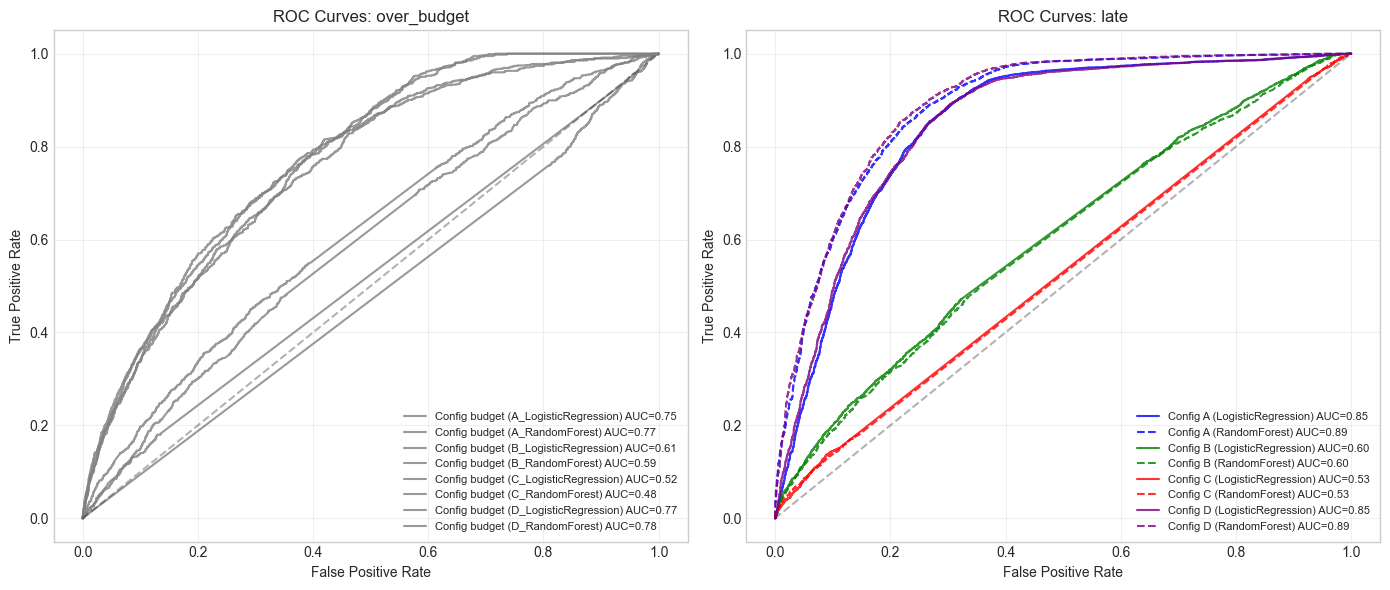

ROC curves saved to: ../figures\roc_curves_comparison.png


In [12]:
# Plot ROC curves for each target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'A': 'blue', 'B': 'green', 'C': 'red', 'D': 'purple'}
linestyles = {'LogisticRegression': '-', 'RandomForest': '--'}

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    
    # Filter models for this target
    target_models = {k: v for k, v in roc_data.items() if k.startswith(target)}
    
    for model_key, roc_info in target_models.items():
        # Parse model key: target_config_algorithm
        parts = model_key.split('_')
        config = parts[1]
        algo = '_'.join(parts[2:])
        
        label = f'Config {config} ({algo}) AUC={roc_info["auc"]:.2f}'
        ax.plot(roc_info['fpr'], roc_info['tpr'], 
                label=label, 
                color=colors.get(config, 'gray'),
                linestyle=linestyles.get(algo, '-'),
                alpha=0.8)
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves: {target}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'roc_curves_comparison.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC curves saved to: {roc_path}')

## 10. Feature Importance (Best RF Models)

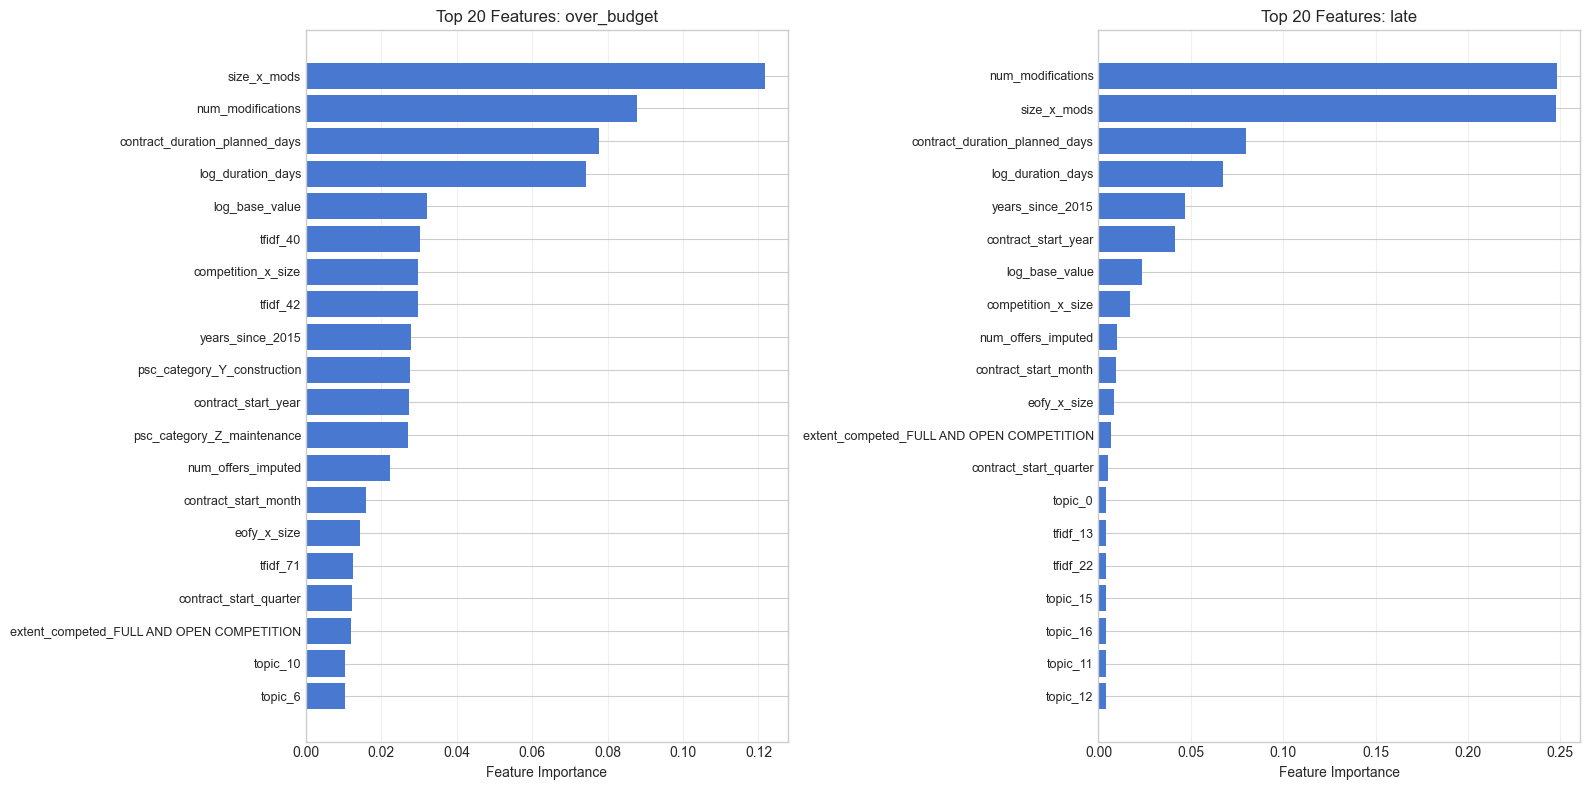

Feature importance saved to: ../figures\feature_importance.png


In [13]:
# Get feature importance from best Random Forest models
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    
    # Find best RF model for this target
    rf_models = {k: v for k, v in trained_models.items() 
                  if k.startswith(target) and k.endswith('RandomForest')}
    
    if not rf_models:
        continue
    
    # Get best by config D (combined) if available, otherwise first
    best_key = f'{target}_D_RandomForest'
    if best_key not in rf_models:
        best_key = list(rf_models.keys())[0]
    
    model_info = rf_models[best_key]
    rf_model = model_info['model']
    feature_names = model_info['feature_names']
    
    # Get top 20 features
    importances = rf_model.feature_importances_
    top_idx = np.argsort(importances)[-20:][::-1]
    
    top_features = [feature_names[i] for i in top_idx]
    top_importance = importances[top_idx]
    
    # Plot
    y_pos = np.arange(len(top_features))
    ax.barh(y_pos, top_importance, align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_features, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Features: {target}')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
fi_path = os.path.join(FIGURES_DIR, 'feature_importance.png')
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Feature importance saved to: {fi_path}')

## 11. Save Trained Models

In [14]:
# Save all trained models
print('Saving trained models...')
saved_models = []

for model_key, model_info in trained_models.items():
    # Create safe filename
    filename = f'{model_key}.pkl'
    filepath = os.path.join(MODELS_DIR, filename)
    
    # Save model and metadata
    save_dict = {
        'model': model_info['model'],
        'scaler': model_info['scaler'],
        'feature_names': model_info['feature_names'],
        'config': model_info['config'],
        'target': model_info['target']
    }
    
    joblib.dump(save_dict, filepath)
    saved_models.append(filename)
    print(f'  Saved: {filename}')

print(f'\nTotal models saved: {len(saved_models)}')

Saving trained models...
  Saved: over_budget_A_LogisticRegression.pkl
  Saved: over_budget_A_RandomForest.pkl
  Saved: over_budget_B_LogisticRegression.pkl


  Saved: over_budget_B_RandomForest.pkl
  Saved: over_budget_C_LogisticRegression.pkl
  Saved: over_budget_C_RandomForest.pkl
  Saved: over_budget_D_LogisticRegression.pkl


  Saved: over_budget_D_RandomForest.pkl
  Saved: late_A_LogisticRegression.pkl
  Saved: late_A_RandomForest.pkl
  Saved: late_B_LogisticRegression.pkl


  Saved: late_B_RandomForest.pkl
  Saved: late_C_LogisticRegression.pkl
  Saved: late_C_RandomForest.pkl
  Saved: late_D_LogisticRegression.pkl
  Saved: late_D_RandomForest.pkl

Total models saved: 16


## 12. Summary

In [15]:
# Final summary
print('=' * 70)
print('PHASE 3 COMPLETE: Classification and Evaluation')
print('=' * 70)

print(f'\nModels Trained: {len(trained_models)}')
print(f'Targets: {TARGETS}')
print(f'Configurations: {list(CONFIGS.keys())}')
print(f'Algorithms: LogisticRegression, RandomForest')

print('\nKey Outputs:')
print(f'  - {RESULTS_PATH}')
print(f'  - {os.path.join(FIGURES_DIR, "roc_curves_comparison.png")}')
print(f'  - {os.path.join(FIGURES_DIR, "feature_importance.png")}')
print(f'  - {MODELS_DIR}/*.pkl ({len(saved_models)} models)')

print('\n' + '=' * 70)
print('Next Steps:')
print('  1. Run 07_gao_validation.ipynb for external validation')
print('  2. Run 08_final_submission.ipynb for master notebook')
print('=' * 70)

PHASE 3 COMPLETE: Classification and Evaluation

Models Trained: 16
Targets: ['over_budget', 'late']
Configurations: ['A', 'B', 'C', 'D']
Algorithms: LogisticRegression, RandomForest

Key Outputs:
  - ../data/processed/results_comparison.csv
  - ../figures\roc_curves_comparison.png
  - ../figures\feature_importance.png
  - ../models/*.pkl (16 models)

Next Steps:
  1. Run 07_gao_validation.ipynb for external validation
  2. Run 08_final_submission.ipynb for master notebook
